# 📊 Etapa 1: Análise Exploratória de Dados (EDA) - Previsão de Churn
**Autor:** Thiago Soares Simões (RM374443)
**Objetivo:** Compreender a saúde dos dados da FIAPMobile e identificar padrões que indiquem a saída de clientes.

### Configuração e Reprodutibilidade (Código)
Aqui estamos fazendo imports necessários e fixando a semente (seed) em 42 para garantirmos resultados reproduziveis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fixando a semente para garantir resultados reproduzíveis
SEED = 42
np.random.seed(SEED)

import warnings
warnings.filterwarnings('ignore')

### Carga de Dados
Nesta etapa, carregamos o dataset Telco Customer Churn para realizar a inspeção inicial 
de tipos e volumes.

In [3]:
# Carga sem tratamentos iniciais para fins de exploração
DATA_PATH = "../data/raw/telco_customer_churn.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape dos dados: {df.shape[0]} registros e {df.shape[1]} colunas")
print(f"\nPrimeiras 10 linhas do dataset:")
df.head(10)

Shape dos dados: 7043 registros e 21 colunas

Primeiras 10 linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### Inspeção Estrutural (Discovery)
Utilizaremos o método `df.info()` para mapear os tipos de dados (Dtypes) e a presença 
de valores nulos. Esta etapa é crucial para identificarmos se as variáveis estão 
no formato correto para os modelos de ML.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Utilizaremos o método `df.describe(include='all')` para analisaremos estatísticas descritivas.
Mostra: `count`, `mean`, `std`, `min`, `25%`, `50%` (mediana), `75%`, `max`.
Útil para entender escala, dispersão e possíveis outliers.

In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


### Análise de Valores Faltantes e Inconsistências
Embora o método `info()` não tenha detectado valores nulos tradicionais (NaN), sabemos que 
campos do tipo `object` podem esconder espaços em branco. Vamos forçar a conversão de 
`TotalCharges` para númerico porque detectamos que ele é do tipo object e contém números e mapear onde os dados realmente faltam.

In [6]:
# Criando uma cópia para não sujar o dataframe original nesta fase de exploração
df_analise = df.copy()

# Forçando a conversão para numérico (espaços viram NaN)
df_analise['TotalCharges'] = pd.to_numeric(df_analise['TotalCharges'], errors='coerce')

# Somando os nulos reais agora
missing_summary = pd.DataFrame({
    'Nulos Reais': df_analise.isnull().sum(),
    'Porcentagem (%)': (df_analise.isnull().sum() / len(df_analise) * 100).round(2)
})

print("Relatório de Dados Faltantes:")
missing_summary[missing_summary['Nulos Reais'] > 0]

Relatório de Dados Faltantes:


,Nulos Reais,Porcentagem (%)
TotalCharges,11,0.16


### Investigação dos Nulos em TotalCharges
Ao quantificarmos 11 valores nulos após a conversão, levantamos a hipótese de que eles 
pertencem a novos clientes. Vamos validar se o `tenure` (meses de casa) desses 
registros é de fato igual a zero.

In [7]:
# Filtrando apenas os registros onde TotalCharges ficou nulo
nulos_total_charges = df_analise[df_analise['TotalCharges'].isnull()]

# Verificando o tempo de casa (tenure) desses clientes
print(f"Meses de casa dos clientes com TotalCharges nulo: {nulos_total_charges['tenure'].unique()}")

print(f"\nInvestigando os {len(nulos_total_charges)} registros:")
display(nulos_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Meses de casa dos clientes com TotalCharges nulo: [0]

Investigando os 11 registros:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


### Tratamento de Dados Faltantes
Decidimos pela imputação do valor **0** para os nulos em `TotalCharges`. 
Esta escolha baseia-se na lógica de que clientes com tempo de casa zero ainda 
não acumularam cobranças. Isso limpa o sinal para o modelo sem descartar informações.

In [8]:
# Aplicando a limpeza: transformando os NaN em 0
df_analise['TotalCharges'] = df_analise['TotalCharges'].fillna(0)

# Validando se ainda restam nulos
restantes = df_analise['TotalCharges'].isnull().sum()
print(f"✅ Tratamento concluído. Nulos restantes em TotalCharges: {restantes}")

✅ Tratamento concluído. Nulos restantes em TotalCharges: 0


### Analisando o balanceamento da classe alvo (Churn)


Distribuição da Variável Alvo (Churn):


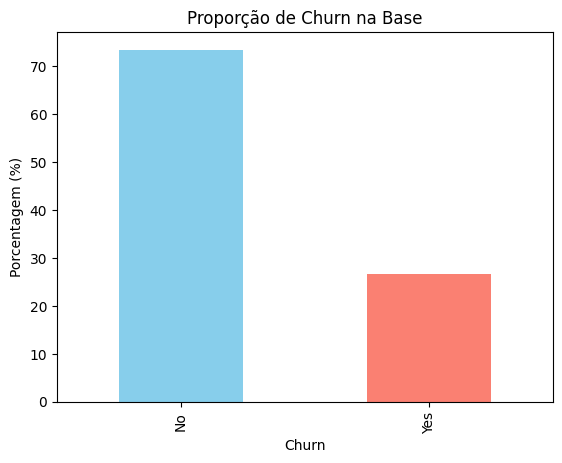

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [9]:
# Analisando o balanceamento da classe alvo
print("Distribuição da Variável Alvo (Churn):")
distribuicao = df_analise['Churn'].value_counts(normalize=True) * 100

# Visualização simples
distribuicao.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Proporção de Churn na Base')
plt.ylabel('Porcentagem (%)')
plt.show()

print(distribuicao)

### Análise da Variável Alvo (Churn)
Identificamos que 26,54% dos clientes da base cancelaram o serviço. Este volume 
indica um desbalanceamento moderado que exige atenção na escolha das métricas.

**Principais conclusões desta análise:**
1. O baseline de acurácia a ser batido é de **73,46%** (Dummy Classifier).
2. A acurácia não será utilizada como métrica única, dado o desbalanceamento.
3. O objetivo de negócio prioriza o **Recall**, visando minimizar a perda de clientes 
não detectados pelo modelo.

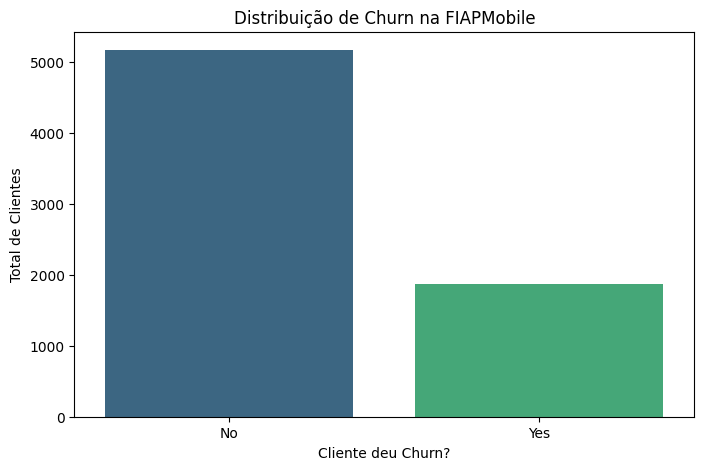

In [10]:
# Verificação visual do desbalanceamento para o relatório
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df_analise, palette='viridis')
plt.title('Distribuição de Churn na FIAPMobile')
plt.xlabel('Cliente deu Churn?')
plt.ylabel('Total de Clientes')
plt.show()

### Análise Bivariada: Variáveis Numéricas vs. Churn
Vamos investigar como o tempo de casa (`tenure`) e as cobranças mensais (`MonthlyCharges`) 
se comportam para clientes que saíram versus os que ficaram. Utilizaremos **KDE Plots** 
(gráficos de densidade) para visualizar essas distribuições.

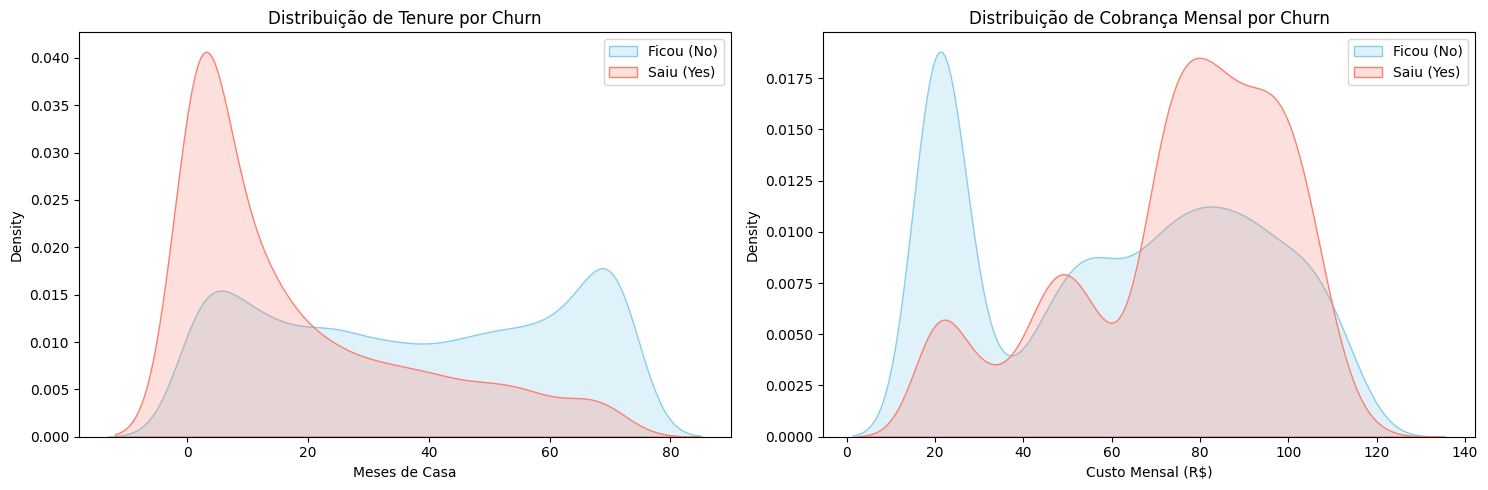

In [11]:
# Configurando a área de plotagem
plt.figure(figsize=(15, 5))

# Plot de Tenure
plt.subplot(1, 2, 1)
sns.kdeplot(df_analise[df_analise['Churn'] == 'No']['tenure'], fill=True, label='Ficou (No)', color='skyblue')
sns.kdeplot(df_analise[df_analise['Churn'] == 'Yes']['tenure'], fill=True, label='Saiu (Yes)', color='salmon')
plt.title('Distribuição de Tenure por Churn')
plt.xlabel('Meses de Casa')
plt.legend()

# Plot de MonthlyCharges
plt.subplot(1, 2, 2)
sns.kdeplot(df_analise[df_analise['Churn'] == 'No']['MonthlyCharges'], fill=True, label='Ficou (No)', color='skyblue')
sns.kdeplot(df_analise[df_analise['Churn'] == 'Yes']['MonthlyCharges'], fill=True, label='Saiu (Yes)', color='salmon')
plt.title('Distribuição de Cobrança Mensal por Churn')
plt.xlabel('Custo Mensal (R$)')
plt.legend()

plt.tight_layout()
plt.show()

**📈 Diagnóstico Visual:**  
1. **Tenure:** Observamos um pico altíssimo de churn nos primeiros meses de contrato. 
Clientes com baixo `tenure` são o grupo de maior risco para a FIAPMobile.
2. **MonthlyCharges:** Clientes com contas mensais mais altas (acima de R$ 70) 
apresentam uma densidade maior de cancelamento, sugerindo sensibilidade ao preço.

### Análise de Variáveis Categóricas (Contratos,Serviços e método de pagamento)
Vamos validar se o tipo de contrato (`Contract`) influencia a decisão de saída. 
Hipótese: Contratos "Month-to-month" (mensais) possuem churn maior por não terem multa de fidelidade.

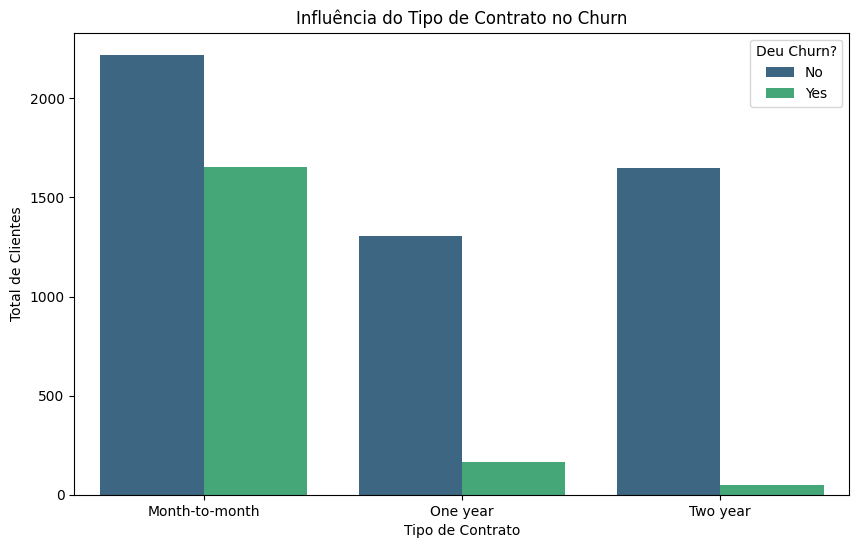

Tabela de Contingência (Contrato vs Churn):


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df_analise, palette='viridis')
plt.title('Influência do Tipo de Contrato no Churn')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Total de Clientes')
plt.legend(title='Deu Churn?')
plt.show()

print("Tabela de Contingência (Contrato vs Churn):")
pd.crosstab(df_analise['Contract'], df_analise['Churn'], normalize='index') * 100

Vamos validar se o serviço de internet (`InternetService`) influencia a decisão de saída. 
Hipótese: Serviços de fibra ótica possuem churn maior.

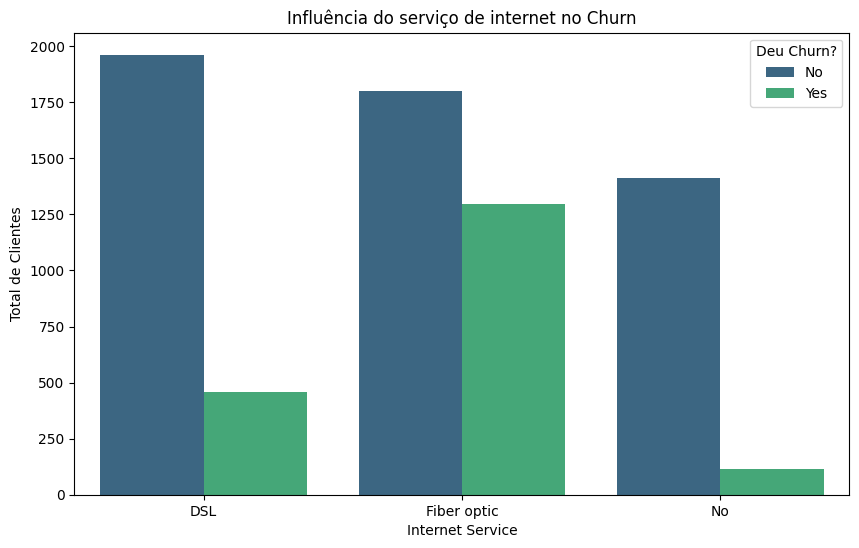

Tabela de Contingência (Serviço de Internet vs Churn):


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df_analise, palette='viridis')
plt.title('Influência do serviço de internet no Churn')
plt.xlabel('Internet Service')
plt.ylabel('Total de Clientes')
plt.legend(title='Deu Churn?')
plt.show()

print("Tabela de Contingência (Serviço de Internet vs Churn):")
pd.crosstab(df_analise['InternetService'], df_analise['Churn'], normalize='index') * 100

Vamos validar se o método de pagamento (`PaymentMethod`) influencia a decisão de saída. 
Hipótese: Electronic check possuem churn maior.

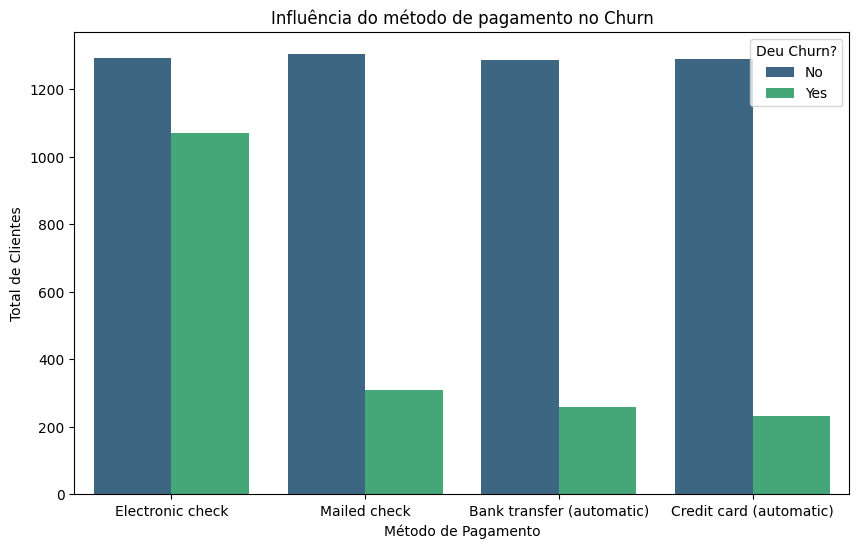

Tabela de Contingência (Método de Pagamento vs Churn):


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df_analise, palette='viridis')
plt.title('Influência do método de pagamento no Churn')
plt.xlabel('Método de Pagamento')
plt.ylabel('Total de Clientes')
plt.legend(title='Deu Churn?')
plt.show()

print("Tabela de Contingência (Método de Pagamento vs Churn):")
pd.crosstab(df_analise['PaymentMethod'], df_analise['Churn'], normalize='index') * 100

### Mapa de Calor de Correlação (Multivariada)
Para visualizarmos a relação de todas as variáveis simultaneamente, aplicaremos o 
**One-Hot Encoding** nas variáveis categóricas. Isso converte textos em números (0 e 1), 
permitindo o cálculo da correlação linear. O objetivo é identificar quais fatores 
têm maior correlação positiva ou negativa com o cancelamento (Churn).

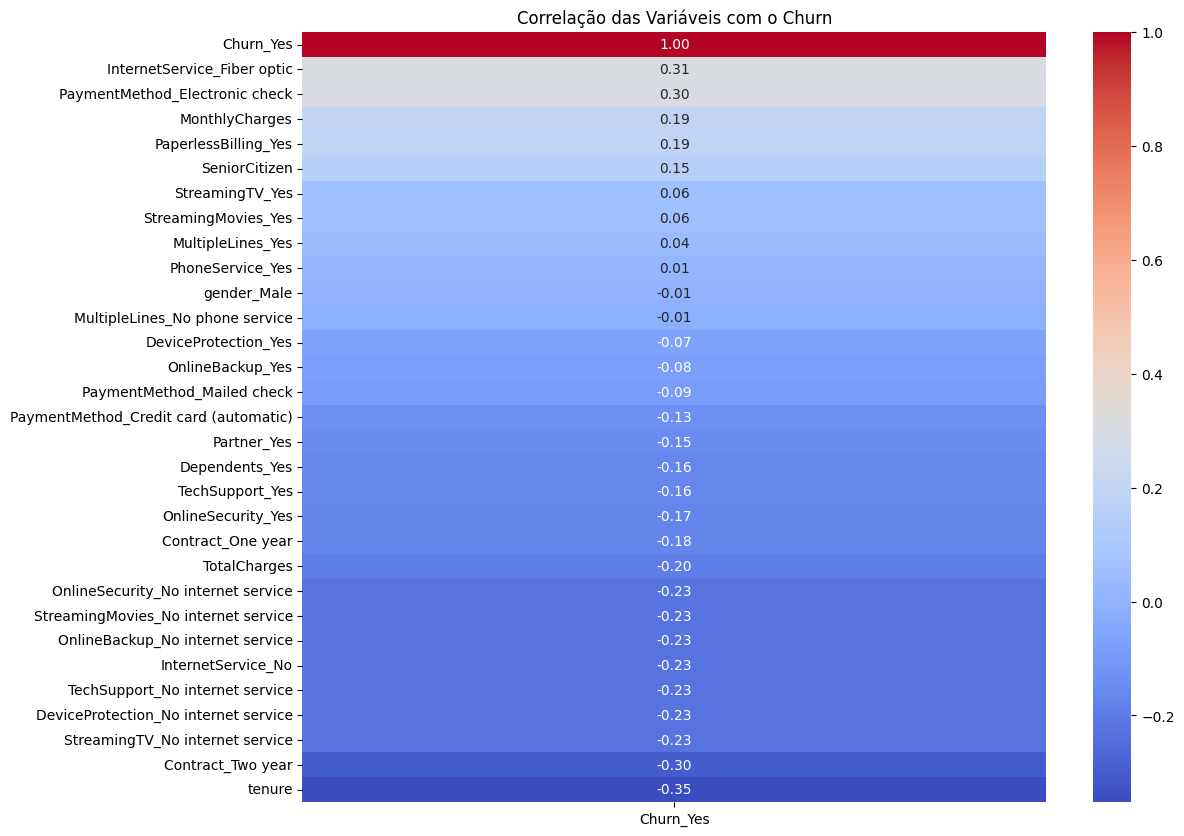

In [ ]:
# 1. Criando um dataframe codificado SEM o customerID
# Colunas como IDs não possuem sinal preditivo e geram excesso de colunas (Overhead)
df_corr = pd.get_dummies(df_analise.drop(columns=['customerID']), drop_first=True)

# 2. Criando um dataframe codificado apenas para a correlação
# drop_first=True evita a armadilha da multicolinearidade (dummy variable trap)
df_corr = pd.get_dummies(df_analise, drop_first=True)

# 3. Calculando a matriz de correlação
corr_matrix = df_corr.corr()

# 4. Plotando o Heatmap focado na relação com o Churn
plt.figure(figsize=(12, 10))
# Filtramos apenas a coluna do Churn para facilitar a leitura
churn_corr = corr_matrix[['Churn_Yes']].sort_values(by='Churn_Yes', ascending=False)

sns.heatmap(churn_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação das Variáveis com o Churn (Yes)')
plt.show()

### Definição da Métrica de Sucesso
Para este projeto de Churn, a métrica técnica prioritária será o **Recall (Revocação)**. 
**Justificativa:** Nosso objetivo é identificar o máximo possível de clientes em risco 
de cancelamento. Um "Falso Negativo" (não prever a saída de um cliente que cancela) 
representa perda de receita direta para a FIAPMobile. O Recall mede a capacidade do 
modelo de encontrar todos os casos positivos reais.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separando as variáveis preditoras (X) do alvo (y)
# Removemos o customerID pois ele não tem poder preditivo
# Removemos o Churn de X pois ele é o nosso alvo
X = df_analise.drop(columns=['customerID', 'Churn'], errors='ignore')
y = df_analise['Churn'].apply(lambda x: 1 if x == 'Yes' else 0) # Convertendo alvo para binário

# 2. Aplicando o One-Hot Encoding definitivo nas variáveis categóricas
X = pd.get_dummies(X, drop_first=True)

# 3. Divisão entre Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dados de Treino: {X_train.shape} amostras")
print(f"Dados de Teste: {X_test.shape} amostras")

Dados de Treino: (5634, 30) amostras
Dados de Teste: (1409, 30) amostras


### Treinamento das baselines

In [26]:
import mlflow
import mlflow.sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, accuracy_score, classification_report

# 1. Configurando o experimento no MLflow
mlflow.set_experiment("Churn_Prediction_FIAPMobile")

# --- EXPERIMENTO 1: Dummy Classifier (Baseline Cego) ---
with mlflow.start_run(run_name="Baseline_Dummy"):
    dummy = DummyClassifier(strategy="stratified", random_state=42)
    dummy.fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)
    
    # Métricas
    rec_dummy = recall_score(y_test, y_pred_dummy)
    acc_dummy = accuracy_score(y_test, y_pred_dummy)
    
    # Log no MLflow
    mlflow.log_param("model_type", "Dummy")
    mlflow.log_metric("recall", rec_dummy)
    mlflow.log_metric("accuracy", acc_dummy)
    mlflow.sklearn.log_model(dummy, "model")
    
    print(f"Dummy Acurácia: {acc_dummy:.2f}")
    print(f"Dummy Recall: {rec_dummy:.2f}")

# --- EXPERIMENTO 2: Regressão Logística (MVP) ---
with mlflow.start_run(run_name="Baseline_Logistica"):
    # Usamos max_iter maior para garantir convergência
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)
    
    # Métricas
    rec_lr = recall_score(y_test, y_pred_lr)
    acc_lr = accuracy_score(y_test, y_pred_lr)
    
    # Log no MLflow
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_metric("recall", rec_lr)
    mlflow.log_metric("accuracy", acc_lr)
    mlflow.sklearn.log_model(lr_model, "model")
    
    print(f"Logística Acurácia: {acc_lr:.2f}")
    print(f"Logística Recall: {rec_lr:.2f}")
    print("\nRelatório de Classificação (Logística):")
    print(classification_report(y_test, y_pred_lr))

2026/05/12 01:17:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 01:17:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Dummy Acurácia: 0.62
Dummy Recall: 0.29


2026/05/12 01:17:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 01:17:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logística Acurácia: 0.80
Logística Recall: 0.56

Relatório de Classificação (Logística):
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### Análise dos Modelos Baseline (MVP)

Nesta etapa, estabelecemos o nosso "piso" de desempenho utilizando dois modelos iniciais. O objetivo foi validar se os dados preparados possuem sinal preditivo útil antes de avançarmos para arquiteturas complexas.

#### Comparativo de Performance (Recall)
*   **Dummy Classifier (Estratificado):** **0.29**
    *   Representa o desempenho de um chute aleatório que respeita as proporções da base. É a nossa régua mínima de "puro acaso".
*   **Regressão Logística (MVP):** **0.56**
    *   O primeiro modelo real alcançou uma capacidade de captura significativamente superior.

#### Conclusões Técnicas
1. **Validação de Sinal:** O modelo logístico superou o baseline cego em aproximadamente **93% (quase o dobro de performance)**. Isso comprova que as variáveis selecionadas e o saneamento dos dados (Data Readiness) permitem que o algoritmo aprenda padrões reais de cancelamento.
2. **Métrica de Negócio (Recall):** Priorizamos o Recall porque, para a FIAPMobile, o custo de um "Falso Negativo" (não identificar um cliente que vai cancelar) é a perda direta de receita. Com este MVP, já conseguimos capturar mais da metade dos cancelamentos potenciais.
3. **Próximos Passos:** Este resultado de **0.56** torna-se a nossa métrica a ser batida (Benchmark). Na Etapa 2, utilizaremos Redes Neurais (MLP com PyTorch) para tentar elevar este Recall, buscando capturar os padrões não-lineares que a Regressão Logística pode ter ignorado.